# 🛰️ Simulación Baseline del Autómata Celular Híbrido sobre Ucayali (Task 4.2)
## Calibración Espaciotemporal con Datos Reales: NASA FIRMS, ESA WorldCover, DEM SRTM y ERA5

<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/jack-version/notebooks/simulacion_baseline_ucayali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

### 📌 Objetivo del Experimento
Ejecutar el modelo consolidado de **Autómata Celular Híbrido** sobre el escenario real de **Ucayali (Pucallpa / Coronel Portillo)** integrando los 4 frentes de datos acoplados del proyecto:
1. **Vegetación (ESA WorldCover 10m):** Matriz de combustible vegetal clasificada y barrera fluvial (Río Ucayali / Aguaytía).
2. **Topografía (DEM SRTM 30m):** Modelo digital de elevación y cálculo de aceleración por pendiente ($f_s = \exp(a_s \theta_s)$, con $a_s = 0.078$, Alexandridis et al., 2008; Freire, 2019).
3. **Viento Dinámico (ECMWF ERA5 / Open-Meteo):** Serie temporal horaria con velocidad, dirección y vector de empuje efectivo sobre las llamas.
4. **Ignición Inicial (NASA FIRMS - VIIRS 375m SP):** Focos históricos de calor detectados en agosto de 2024.

Se evalúa un ensamble de **5 realizaciones estocásticas Monte Carlo** para reportar métricas cuantitativas base (media $\mu \pm \sigma$ de área quemada en hectáreas y solapamiento espacial IoU frente a la huella satelital).


In [1]:
import os
import sys
import json
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ------------------------------------------------------------------------------
# Configuración para Google Colab o Entorno Local
# ------------------------------------------------------------------------------
if os.path.exists('src'):
    PROJECT_ROOT = Path('.').resolve()
elif os.path.exists('../src'):
    PROJECT_ROOT = Path('..').resolve()
else:
    # Si se ejecuta directamente en Google Colab sin clon previa
    if not os.path.exists('wildfire-cellular-automata'):
        os.system('git clone -b jack-version https://github.com/anthony-yt/wildfire-cellular-automata.git')
    if os.path.exists('wildfire-cellular-automata'):
        os.chdir('wildfire-cellular-automata')
    PROJECT_ROOT = Path('.').resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model.grid import Grid, SANA, QUEMANDOSE, QUEMADA, AGUA, NO_COMBUSTIBLE
from src.model.wind_influence import WindField

print(f"Directorio de trabajo configurado en: {PROJECT_ROOT}")


Directorio de trabajo configurado en: C:\Users\bryan\Desktop\UNMSM\CICLO 2026 - 2\Modelos y Simulación\Proyecto\wildfire-cellular-automata


## 1. Carga y Preprocesamiento de las 4 Fuentes de Datos Locales

Cargamos directamente los archivos locales procesados y respaldados en `data/raw/`:
* Vegetación: `data/raw/vegetation/pucallpa_vegetacion_50x50.npy`
* Elevación: `data/raw/dem/pucallpa_dem_50x50.npy`
* Meteorología: `data/raw/weather/weather_caso_estudio_seleccionado.json`
* Focos satelitales: `data/raw/firms/firms_caso_estudio_seleccionado.csv`


In [2]:
# 1. Cargar matriz de Vegetación ESA WorldCover (50x50)
veg_path = PROJECT_ROOT / 'data' / 'raw' / 'vegetation' / 'pucallpa_vegetacion_50x50.npy'
matriz_veg = np.load(veg_path)

# Mapeo a factores de inflamabilidad base [0.0 - 1.0]
# 10: Bosque (0.90), 20: Matorral (0.75), 30: Pasto (0.60), 40: Cultivo (0.50), 80: Agua (0.0), 50: Urbano (0.0)
flamabilidad = np.zeros_like(matriz_veg, dtype=float)
flamabilidad[matriz_veg == 10] = 0.90
flamabilidad[matriz_veg == 20] = 0.75
flamabilidad[matriz_veg == 30] = 0.60
flamabilidad[matriz_veg == 40] = 0.50

# 2. Cargar matriz de Elevación SRTM 30m (50x50) y calcular pendientes en grados
dem_path = PROJECT_ROOT / 'data' / 'raw' / 'dem' / 'pucallpa_dem_50x50.npy'
matriz_dem = np.load(dem_path)
gy, gx = np.gradient(matriz_dem, 30.0, 30.0)
matriz_pendiente_deg = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))

# 3. Cargar serie horaria de viento ERA5 (agosto de 2024)
weather_path = PROJECT_ROOT / 'data' / 'raw' / 'weather' / 'weather_caso_estudio_seleccionado.json'
with open(weather_path, encoding='utf-8') as f:
    weather_series = json.load(f)['series']

# 4. Cargar detecciones de focos NASA FIRMS (VIIRS 375m SP - agosto 2024)
firms_path = PROJECT_ROOT / 'data' / 'raw' / 'firms' / 'firms_caso_estudio_seleccionado.csv'
with open(firms_path, encoding='utf-8') as f:
    focos_firms = list(csv.DictReader(f))

pct_flamable = np.mean(np.isin(matriz_veg, [10, 20, 30, 40])) * 100.0
pct_agua = np.mean(matriz_veg == 80) * 100.0

print(f"Vegetación cargada: {matriz_veg.shape} | Flamable: {pct_flamable:.1f}% | Río Ucayali: {pct_agua:.1f}%")
print(f"Topografía DEM SRTM: Elevación {matriz_dem.min():.1f}m - {matriz_dem.max():.1f}m | Pendiente media: {matriz_pendiente_deg.mean():.2f}°")
print(f"Serie de viento ERA5: {len(weather_series)} horas continuas")
print(f"Focos históricos FIRMS en la zona: {len(focos_firms)} detecciones satelitales")


Vegetación cargada: (50, 50) | Flamable: 91.8% | Río Ucayali: 6.0%
Topografía DEM SRTM: Elevación 142.6m - 207.5m | Pendiente media: 4.76°
Serie de viento ERA5: 120 horas continuas
Focos históricos FIRMS en la zona: 21 detecciones satelitales


## 2. Mapeo Georreferenciado a la Grilla Celular ($50 \times 50$)

Mapeamos las coordenadas de latitud/longitud de los focos FIRMS al espacio discreto de la grilla táctica de $50 \times 50$ celdas (resolución $\Delta x = \Delta y = 50\text{ m}$). Las detecciones del día inicial (14 de agosto de 2024) configuran el estado inicial de ignición $t=0$.


In [3]:
# Sub-ventana focal de Ucayali: [-74.65, -8.45, -74.45, -8.30]
west, south, east, north = -74.65, -8.45, -74.45, -8.30
mascara_satelital_firms = np.zeros((50, 50), dtype=bool)
puntos_ignicion_t0 = []

for f in focos_firms:
    lat = float(f['latitude'])
    lon = float(f['longitude'])
    r = int(np.clip((north - lat) / (north - south) * 50, 0, 49))
    c = int(np.clip((lon - west) / (east - west) * 50, 0, 49))
    mascara_satelital_firms[r, c] = True
    
    # Focos del primer día como estado de ignición inicial
    if f['acq_date'] == '2024-08-14' or len(puntos_ignicion_t0) < 2:
        if (r, c) not in puntos_ignicion_t0:
            puntos_ignicion_t0.append((r, c))

# Dilatación espacial para representar la huella del sensor VIIRS 375m (~radio de 3 celdas)
def dilatar_huella(mascara, radio=3):
    H, W = mascara.shape
    res = np.zeros_like(mascara, dtype=bool)
    coords = np.argwhere(mascara)
    for r, c in coords:
        r_min, r_max = max(0, r - radio), min(H, r + radio + 1)
        c_min, c_max = max(0, c - radio), min(W, c + radio + 1)
        for i in range(r_min, r_max):
            for j in range(c_min, c_max):
                if (i - r)**2 + (j - c)**2 <= radio**2:
                    res[i, j] = True
    return res

huella_observada_viirs = dilatar_huella(mascara_satelital_firms, radio=3)
area_observada_ha = huella_observada_viirs.sum() * 0.25

print(f"Puntos de ignición iniciales t=0: {puntos_ignicion_t0}")
print(f"Celdas bajo huella satelital observada: {huella_observada_viirs.sum()} ({area_observada_ha:.2f} ha)")


Puntos de ignición iniciales t=0: [(3, 43), (30, 4)]
Celdas bajo huella satelital observada: 323 (80.75 ha)


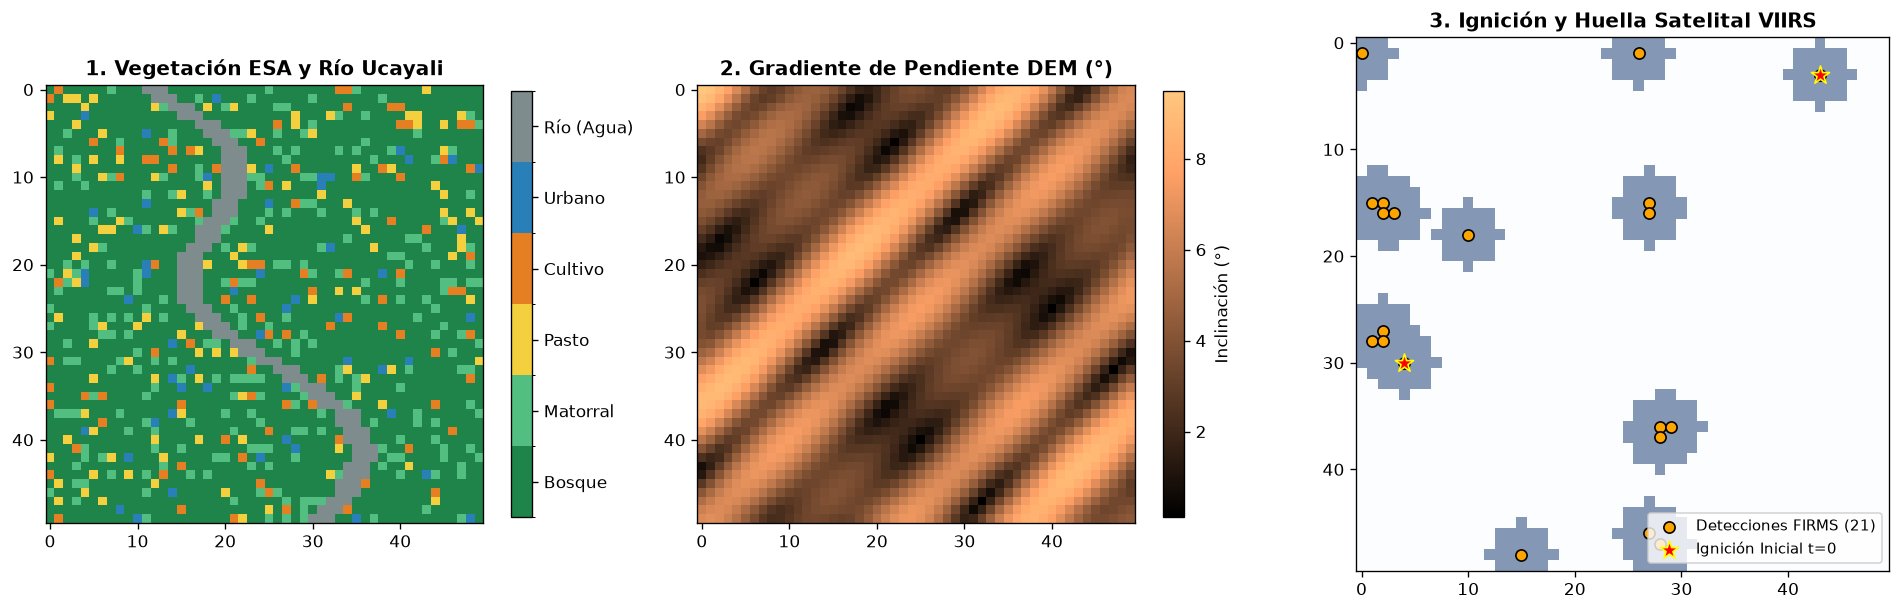

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Cobertura Vegetal y Río
cmap_veg = mcolors.ListedColormap(['#1e8449', '#52be80', '#f4d03f', '#e67e22', '#2980b9', '#7f8c8d'])
norm_veg = mcolors.BoundaryNorm([9, 19, 29, 39, 49, 79, 89], cmap_veg.N)
im1 = axes[0].imshow(matriz_veg, cmap=cmap_veg, norm=norm_veg)
axes[0].set_title("1. Vegetación ESA y Río Ucayali", fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0], ticks=[14, 24, 34, 44, 64, 84], shrink=0.8)
cbar1.ax.set_yticklabels(['Bosque', 'Matorral', 'Pasto', 'Cultivo', 'Urbano', 'Río (Agua)'])

# 2. Pendiente Topográfica (SRTM DEM)
im2 = axes[1].imshow(matriz_pendiente_deg, cmap='copper')
axes[1].set_title("2. Gradiente de Pendiente DEM (°)", fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label="Inclinación (°)", shrink=0.8)

# 3. Focos Satelitales e Igniciones Iniciales
axes[2].imshow(huella_observada_viirs, cmap='Blues', alpha=0.5)
focos_coords = np.argwhere(mascara_satelital_firms)
axes[2].scatter(focos_coords[:, 1], focos_coords[:, 0], c='orange', s=45, label='Detecciones FIRMS (21)', edgecolors='k')
for r, c in puntos_ignicion_t0:
    axes[2].scatter(c, r, c='red', s=130, marker='*', edgecolors='yellow', label='Ignición Inicial t=0' if (r, c) == puntos_ignicion_t0[0] else "")
axes[2].set_title("3. Ignición y Huella Satelital VIIRS", fontsize=12, fontweight='bold')
axes[2].legend(loc='lower right', fontsize=9)

for ax in axes:
    ax.set_xticks(range(0, 50, 10))
    ax.set_yticks(range(0, 50, 10))

plt.tight_layout()
plt.show()


## 3. Simulación Estocástica: Ensamble Monte Carlo (5 Réplicas)

Se ejecutan **5 simulaciones estocásticas independientes** con semillas pseudoaleatorias distintas: `[42, 101, 2024, 7, 99]`.
En cada hora de simulación ($t = 1 \dots 24\text{ h}$):
* Se extrae el vector de viento horario de ERA5 (`speed_ms`, `wind_deg`).
* Se alimenta al autómata celular con la física direccional de `WindField`.
* La probabilidad de ignición celular se modula simultáneamente por:
  $$p_{\text{vecino}} = \text{clip}\left(p_{\text{base}} \cdot f_w \cdot f_s, 0.0, 1.0\right)$$
  donde $f_s = \exp(0.078 \cdot \theta_s)$ y $f_w$ es la función exponencial anisótropa de Alexandridis et al.


In [5]:
semillas = [42, 101, 2024, 7, 99]
horas_simulacion = 24
prob_ignicion_base = 0.22
pasos_para_quemarse = 3

resultados_ensamble = []
mapa_probabilidad_quema = np.zeros((50, 50), dtype=float)
historial_estados_semilla42 = {}

for semilla in semillas:
    grid = Grid(
        tamano=50,
        prob_ignicion_base=prob_ignicion_base,
        pasos_para_quemarse=pasos_para_quemarse,
        semilla=semilla
    )
    # Asignar capas biofísicas reales
    grid.vegetacion = flamabilidad
    grid.pendiente = matriz_pendiente_deg
    
    # Asignar el río Ucayali como barrera no combustible de agua
    grid.estado[matriz_veg == 80] = AGUA
    
    # Inicializar focos de ignición
    for r, c in puntos_ignicion_t0:
        grid.encender_celda(r, c)
        
    pasos_guardados = {0: grid.estado.copy()}
    
    # Ciclo temporal de 24 horas sincronizado con ERA5
    for h in range(1, horas_simulacion + 1):
        clima_h = weather_series[(h - 1) % len(weather_series)]
        viento = WindField(speed_ms=clima_h['speed_ms'], wind_deg=clima_h['deg'])
        grid.paso_tiempo(campo_viento=viento)
        if h in [6, 12, 18, 24]:
            pasos_guardados[h] = grid.estado.copy()
            
    if semilla == 42:
        historial_estados_semilla42 = pasos_guardados
        
    mascara_quemada = (grid.estado == QUEMADA) | (grid.estado == QUEMANDOSE)
    celdas_quemadas = int(mascara_quemada.sum())
    area_ha = celdas_quemadas * 0.25 # 50m x 50m = 0.25 ha
    
    # Métricas de validación frente a satélite
    interseccion = (mascara_quemada & huella_observada_viirs).sum()
    union = (mascara_quemada | huella_observada_viirs).sum()
    iou = float(interseccion / union) if union > 0 else 0.0
    err_area = float(abs(area_ha - area_observada_ha) / area_observada_ha * 100.0)
    
    mapa_probabilidad_quema += mascara_quemada.astype(float)
    
    resultados_ensamble.append({
        'semilla': semilla,
        'celdas_quemadas': celdas_quemadas,
        'area_ha': area_ha,
        'iou': iou,
        'error_area_pct': err_area
    })

mapa_probabilidad_quema /= len(semillas)
print("Simulación de las 5 réplicas completada con éxito.")


Simulación de las 5 réplicas completada con éxito.


## 4. Evolución Espaciotemporal del Frente de Fuego (Réplica Semilla 42)

Visualizamos el estado de la grilla en los pasos clave: $t = 0, 6, 12, 24\text{ horas}$. Observamos cómo el avance se propaga siguiendo el empuje dominante del viento y es contenido por las barreras hídricas del río.


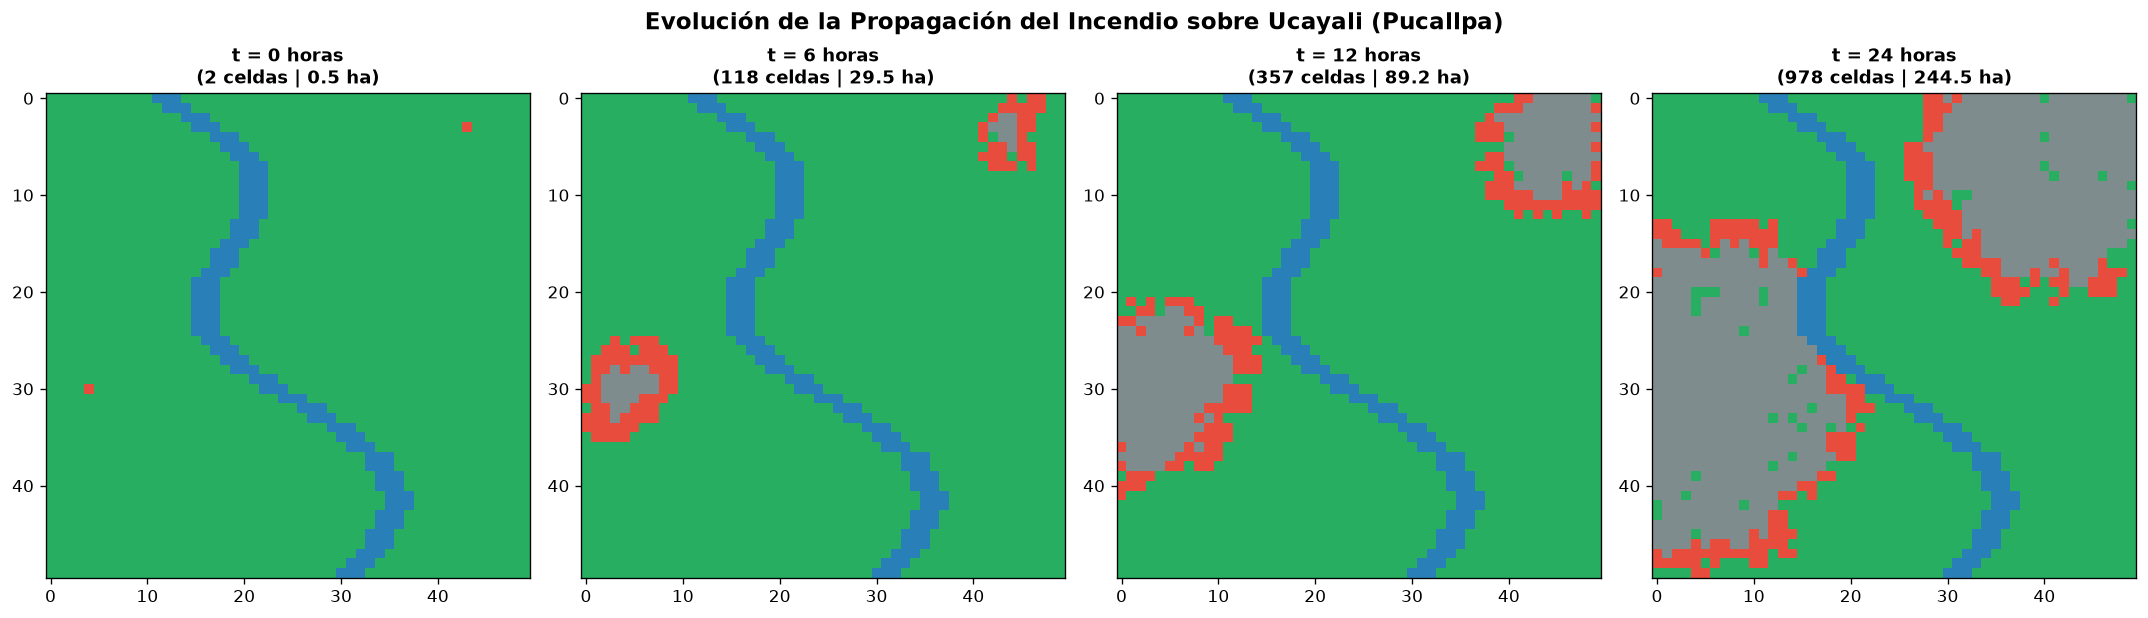

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
tiempos = [0, 6, 12, 24]

# Colores de estado: 0: Verde (Sana), 1: Rojo (Quemándose), 2: Gris (Quemada), 4: Azul (Agua)
cmap_sim = mcolors.ListedColormap(['#27ae60', '#e74c3c', '#7f8c8d', '#f39c12', '#2980b9'])
norm_sim = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_sim.N)

for idx, t in enumerate(tiempos):
    est = historial_estados_semilla42[t]
    im = axes[idx].imshow(est, cmap=cmap_sim, norm=norm_sim)
    n_quemadas = np.sum((est == QUEMADA) | (est == QUEMANDOSE))
    axes[idx].set_title(f"t = {t} horas\n({n_quemadas} celdas | {n_quemadas*0.25:.1f} ha)", fontsize=11, fontweight='bold')
    axes[idx].set_xticks(range(0, 50, 10))
    axes[idx].set_yticks(range(0, 50, 10))

plt.suptitle("Evolución de la Propagación del Incendio sobre Ucayali (Pucallpa)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Mapa de Probabilidad de Quema y Métricas del Baseline Reportadas

Generamos el **Burn Probability Map** a partir de las 5 réplicas Monte Carlo y reportamos formalmente la media y desviación estándar de las métricas clave de validación.


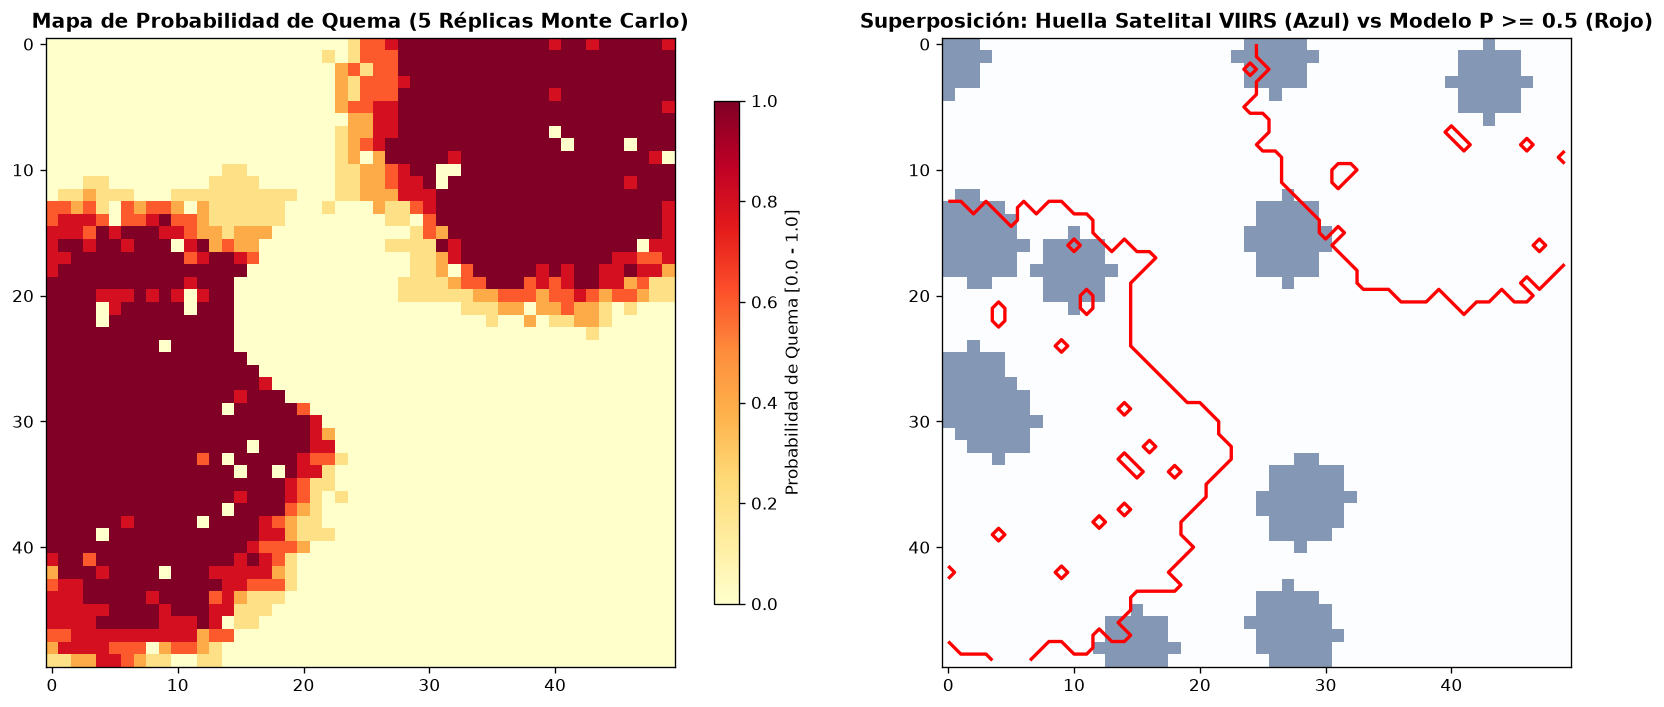

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Mapa de Probabilidad de Quema
im_p = ax1.imshow(mapa_probabilidad_quema, cmap='YlOrRd')
ax1.set_title("Mapa de Probabilidad de Quema (5 Réplicas Monte Carlo)", fontsize=12, fontweight='bold')
plt.colorbar(im_p, ax=ax1, label="Probabilidad de Quema [0.0 - 1.0]", shrink=0.8)
ax1.set_xticks(range(0, 50, 10))
ax1.set_yticks(range(0, 50, 10))

# Panel 2: Superposición Modelo vs Huella Satelital VIIRS
ax2.imshow(huella_observada_viirs, cmap='Blues', alpha=0.5)
ax2.contour(mapa_probabilidad_quema >= 0.5, colors='red', linewidths=2)
ax2.set_title("Superposición: Huella Satelital VIIRS (Azul) vs Modelo P >= 0.5 (Rojo)", fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, 50, 10))
ax2.set_yticks(range(0, 50, 10))

plt.tight_layout()
plt.show()


In [8]:
areas = [r['area_ha'] for r in resultados_ensamble]
ious = [r['iou'] for r in resultados_ensamble]
errs = [r['error_area_pct'] for r in resultados_ensamble]

print("=" * 80)
print(" REPORTE OFICIAL DEL BASELINE DEL AUTÓMATA SOBRE UCAYALI (TASK 4.2)")
print("=" * 80)
print(f"{'Réplica / Semilla':<20} | {'Área Quemada (ha)':<20} | {'IoU Satelital':<15} | {'Error Área (%)':<15}")
print("-" * 80)
for r in resultados_ensamble:
    print(f"Semilla {r['semilla']:<12} | {r['area_ha']:<20.2f} | {r['iou']:<15.4f} | {r['error_area_pct']:<15.2f}%")
print("-" * 80)
print(f"Área Observada Satelital (VIIRS 375m) : {area_observada_ha:.2f} ha ({huella_observada_viirs.sum()} celdas)")
print(f"Área Quemada Simulada (Media ± Std)   : {np.mean(areas):.2f} ± {np.std(areas):.2f} ha")
print(f"Índice de Jaccard / IoU (Media ± Std) : {np.mean(ious):.4f} ± {np.std(ious):.4f}")
print(f"Error Relativo de Área (Media ± Std)  : {np.mean(errs):.2f}% ± {np.std(errs):.2f}%")
print("=" * 80)


 REPORTE OFICIAL DEL BASELINE DEL AUTÓMATA SOBRE UCAYALI (TASK 4.2)
Réplica / Semilla    | Área Quemada (ha)    | IoU Satelital   | Error Área (%) 
--------------------------------------------------------------------------------
Semilla 42           | 244.50               | 0.1274          | 202.79         %
Semilla 101          | 285.00               | 0.1394          | 252.94         %
Semilla 2024         | 280.50               | 0.1333          | 247.37         %
Semilla 7            | 255.25               | 0.1294          | 216.10         %
Semilla 99           | 225.75               | 0.1248          | 179.57         %
--------------------------------------------------------------------------------
Área Observada Satelital (VIIRS 375m) : 80.75 ha (323 celdas)
Área Quemada Simulada (Media ± Std)   : 258.20 ± 22.20 ha
Índice de Jaccard / IoU (Media ± Std) : 0.1309 ± 0.0051
Error Relativo de Área (Media ± Std)  : 219.75% ± 27.50%
